In [1]:
import pandas as pd
import numpy as np

In [2]:
# Read CSV
df = pd.read_csv('movies.csv')

In [3]:
df.head()

,Unnamed: 0,id,title,overview,release_date,popularity,vote_average,vote_count
0,0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,28.5896,8.715,29563
1,1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,35.1703,8.687,22324
2,2,240,The Godfather Part II,In the continuing saga of the Corleone crime f...,1974-12-20,20.0531,8.570,13500
3,3,424,Schindler's List,The true story of how businessman Oskar Schind...,1993-12-15,15.2219,8.566,17014
4,4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,13.5475,8.552,9672


In [4]:
# Inspect data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    10000 non-null  int64  
 1   id            10000 non-null  int64  
 2   title         10000 non-null  object 
 3   overview      9999 non-null   object 
 4   release_date  9998 non-null   object 
 5   popularity    10000 non-null  float64
 6   vote_average  10000 non-null  float64
 7   vote_count    10000 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 625.1+ KB
None


In [6]:
df.describe()

,Unnamed: 0,id,popularity,vote_average,vote_count
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000
mean,4999.50000,2.234481e+05,3.900632,6.722426,2069.828300
std,2886.89568,2.962378e+05,8.672663,0.665520,3301.115501
min,0.00000,2.000000e+00,0.002700,5.389000,300.000000
25%,2499.75000,1.032875e+04,1.612200,6.203000,474.000000
50%,4999.50000,4.150150e+04,2.639900,6.700000,866.000000
75%,7499.25000,4.014868e+05,4.492600,7.202000,2069.250000
max,9999.00000,1.472638e+06,566.971000,8.715000,38660.000000


In [7]:
# Drop unnecessary columns
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

In [8]:
# Handle Missing Values
print(df.isnull().sum())

id              0
title           0
overview        1
release_date    2
popularity      0
vote_average    0
vote_count      0
dtype: int64


In [9]:
# Detect missing values
df['overview'] = df['overview'].fillna('No Overview Available')

In [10]:
# Drop rows where 'release_date' is missing
df = df.dropna(subset=['release_date'])

In [11]:
# Strip whitespace and standardize case
df['title'] = df['title'].str.strip().str.title()

In [12]:
# Type Conversion & Datetime Extraction
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

In [13]:
median_timestamp = df["release_date"].astype("int64").median()
median_date = pd.to_datetime(median_timestamp)
df["release_date"] = df["release_date"].fillna(median_date)

In [14]:
df['release_year'] = pd.to_datetime(df['release_date']).dt.year.astype(int)

In [15]:
# Handle Duplicates
df = df.drop_duplicates(subset=['id'], keep='first')

In [16]:
# Outlier Detection and Treatment (using IQR on vote_count)
Q1 = df['vote_count'].quantile(0.25)
Q3 = df['vote_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [17]:
# Cap outliers to the upper bound rather than deleting them
df.loc[df['vote_count'] > upper_bound, 'vote_count'] = upper_bound

In [18]:
pop = df['popularity'].to_numpy()

In [19]:
print(f"First 10 popularity scores: {pop[:10]}")

First 10 popularity scores: [28.5896 35.1703 20.0531 15.2219 13.5475 17.7179 24.2045  5.9882 21.3484
 27.826 ]


In [20]:
#or
print(df[['title', 'popularity']].head(10))

                         title  popularity
0     The Shawshank Redemption     28.5896
1                The Godfather     35.1703
2        The Godfather Part Ii     20.0531
3             Schindler'S List     15.2219
4                 12 Angry Men     13.5475
5                Spirited Away     17.7179
6              The Dark Knight     24.2045
7  Dilwale Dulhania Le Jayenge      5.9882
8               The Green Mile     21.3484
9                     Parasite     27.8260


In [21]:
# Statistical calculations
med_pop = np.median(pop)
mean_pop = np.mean(pop)
std_pop = np.std(pop)
per_90 = np.percentile(pop,90)

In [22]:
print(f"Popularity - Mean: {mean_pop:.2f}, Median: {med_pop:.2f}, Std: {std_pop:.2f}, 90th Pct: {per_90:.2f}")

Popularity - Mean: 3.91, Median: 2.64, Std: 8.71, 90th Pct: 7.01


In [23]:
# Mathematical operations (Log transformation to handle skewness)
df['log_popularity'] = np.log1p(pop)

In [24]:
# Filtering with np.where (Create a new categorical column based on condition)
df['is_highly_popular'] = np.where(pop > per_90, 'Yes', 'No')

In [25]:
# Reshaping arrays (Demonstration)
reshaped_array = pop[:100].reshape(10, 10)

In [60]:
reshaped_array

array([[2.85896e+01, 3.51703e+01, 2.00531e+01, 1.52219e+01, 1.35475e+01,
        1.77179e+01, 2.42045e+01, 5.98820e+00, 2.13484e+01, 2.78260e+01],
       [2.29764e+01, 1.99151e+01, 1.97788e+01, 1.24567e+01, 5.00813e+01,
        2.04646e+01, 1.69359e+01, 8.00250e+00, 8.00000e-03, 9.09350e+00],
       [2.81498e+01, 5.33180e+00, 5.49350e+00, 7.50260e+00, 2.74982e+01,
        2.85290e+00, 4.09150e+00, 9.01760e+00, 8.72960e+00, 1.89299e+01],
       [3.90910e+00, 1.44613e+01, 2.65860e+00, 8.44360e+00, 8.64660e+00,
        1.40429e+01, 7.33120e+00, 1.71980e+01, 1.22664e+01, 1.49792e+01],
       [7.16200e-01, 2.74050e+01, 3.67480e+00, 6.71250e+00, 1.70920e+00,
        4.79290e+00, 3.26640e+00, 6.71220e+00, 2.24975e+01, 7.43020e+00],
       [5.17130e+00, 1.93102e+01, 5.17580e+00, 9.22620e+00, 7.03560e+00,
        1.74326e+01, 4.46470e+01, 1.15711e+01, 5.05380e+00, 1.16439e+01],
       [5.52260e+00, 6.35530e+00, 2.75390e+00, 2.93780e+00, 6.87100e-01,
        3.12770e+00, 2.45670e+00, 2.48680e+00

In [26]:
df.head()

,id,title,overview,release_date,popularity,vote_average,vote_count,release_year,log_popularity,is_highly_popular
0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,28.5896,8.715,4464,1994,3.387423,Yes
1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,35.1703,8.687,4464,1972,3.588238,Yes
2,240,The Godfather Part Ii,In the continuing saga of the Corleone crime f...,1974-12-20,20.0531,8.570,4464,1974,3.047048,Yes
3,424,Schindler'S List,The true story of how businessman Oskar Schind...,1993-12-15,15.2219,8.566,4464,1993,2.786362,Yes
4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,13.5475,8.552,4464,1957,2.677419,Yes


In [27]:
# Grouping and Aggregation
yearly_stats = df.groupby('release_year').agg({
    'vote_average': 'mean',
    'title': 'count'
}).rename(columns={'title': 'movie_count'})

In [29]:
# Filter out years with very few movies to reduce noise
yearly_stats = yearly_stats[yearly_stats['movie_count'] > 10].reset_index()

In [30]:
yearly_stats

,release_year,vote_average,movie_count
0,1946,7.533615,13
1,1948,7.504182,11
2,1950,7.560364,11
3,1953,7.275857,21
4,1954,7.450053,19
...,...,...,...
71,2021,6.839697,327
72,2022,6.804325,314
73,2023,6.828429,261
74,2024,6.710820,217


In [31]:
top_rated_movies = df[df['vote_count'] > 500].sort_values(by='vote_average', ascending=False).head(5)

In [32]:
top_rated_movies

,id,title,overview,release_date,popularity,vote_average,vote_count,release_year,log_popularity,is_highly_popular
0,278,The Shawshank Redemption,Imprisoned in the 1940s for the double murder ...,1994-09-23,28.5896,8.715,4464,1994,3.387423,Yes
1,238,The Godfather,"Spanning the years 1945 to 1955, a chronicle o...",1972-03-14,35.1703,8.687,4464,1972,3.588238,Yes
2,240,The Godfather Part Ii,In the continuing saga of the Corleone crime f...,1974-12-20,20.0531,8.570,4464,1974,3.047048,Yes
3,424,Schindler'S List,The true story of how businessman Oskar Schind...,1993-12-15,15.2219,8.566,4464,1993,2.786362,Yes
4,389,12 Angry Men,The defense and the prosecution have rested an...,1957-04-10,13.5475,8.552,4464,1957,2.677419,Yes


In [33]:
# Splitting dataframe to demonstrate a merge on 'id'
df_titles = df[['id', 'title', 'release_year']]
df_metrics = df[['id', 'popularity', 'vote_average']]
merged_df = pd.merge(df_titles, df_metrics, on='id', how='inner')

In [34]:
merged_df.head()

,id,title,release_year,popularity,vote_average
0,278,The Shawshank Redemption,1994,28.5896,8.715
1,238,The Godfather,1972,35.1703,8.687
2,240,The Godfather Part Ii,1974,20.0531,8.570
3,424,Schindler'S List,1993,15.2219,8.566
4,389,12 Angry Men,1957,13.5475,8.552


In [35]:
df.to_csv('cleaned_movies.csv', index=False)

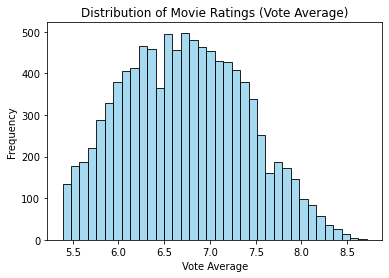

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Distribution of Vote Averages (Histogram)
sns.histplot(x=df['vote_average'],color='skyblue')

plt.title('Distribution of Movie Ratings (Vote Average)')
plt.xlabel('Vote Average')
plt.ylabel('Frequency')

plt.show()

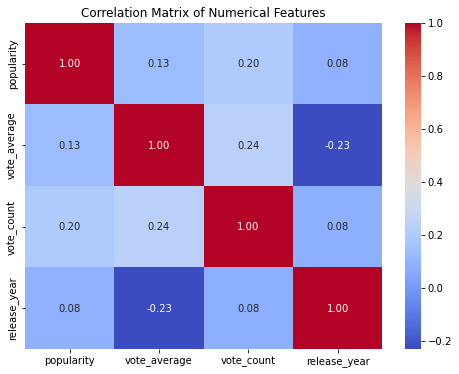

In [44]:
# Plot 2: Correlation Heatmap

plt.figure(figsize=(8, 6))
num_cols = df[['popularity', 'vote_average', 'vote_count', 'release_year']]
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

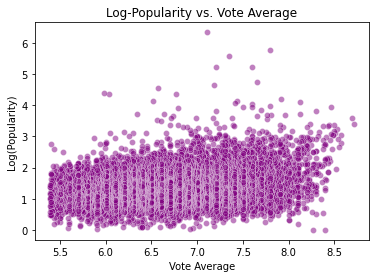

In [61]:
# Plot 3: Popularity vs. Vote Average (Scatter Plot)
sns.scatterplot(data=df, x='vote_average', y='log_popularity', alpha=0.5, color='purple')
plt.title('Log-Popularity vs. Vote Average')
plt.xlabel('Vote Average')
plt.ylabel('Log(Popularity)')
plt.savefig('outputs/popularity_vs_rating.png')
plt.show()

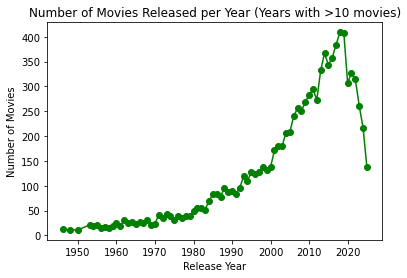


Analysis complete!


In [62]:
# Plot 4: Number of Movies Released Over Time (Line Chart)
x_data = yearly_stats['release_year'].values
y_data = yearly_stats['movie_count'].values

plt.plot(x_data, y_data, color='green', marker='o', linestyle='-')

plt.title('Number of Movies Released per Year (Years with >10 movies)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies')
plt.savefig('outputs/movies_over_time.png')
plt.show()

print("\nAnalysis complete!")